# **Pipeline**

Luis Felipe Villota

InSight Crime - MAD Unit 

---------------------


In [3]:
import time

start_time = time.time()
formatted_start_time = time.ctime(start_time)
print(f"Start time: {formatted_start_time}")

Start time: Sat Apr  4 18:30:13 2026


## Setup

#### Version Control

The project is created within a single GitHub repository ([FelipeVillota/ic-prizes_and_awards](https://github.com/FelipeVillota/ic-prizes)). I keep the repository `private` with the possibility to give access to the online repo at any time. 

#### Environment

In [ ]:
import os
import subprocess
import sys
import platform
from pathlib import Path

# ==============================
# CONFIG
# ==============================
VENV_NAME = "venv-cuina"
KERNEL_NAME = "cuina-kernel"
DISPLAY_NAME = "Python (cuina)"

PACKAGES = [
    "gspread", "pandas", "requests", "google-api-python-client",
    "oauth2client", "matplotlib", "seaborn", "missingno",
    "gspread-formatting", "ipykernel", "openpyxl",
    "gspread-dataframe", "pytz", "feedparser"
]

# ==============================
# PATH SETUP (CROSS PLATFORM)
# ==============================
project_dir = Path.cwd()
venv_path = project_dir / VENV_NAME

if platform.system() == "Windows":
    venv_python = venv_path / "Scripts" / "python.exe"
else:
    venv_python = venv_path / "bin" / "python"

# ==============================
# 1. CREATE VENV
# ==============================
if not venv_path.exists():
    print(f"🔧 Creating virtual environment: {VENV_NAME}")
    try:
        subprocess.run([sys.executable, "-m", "venv", str(venv_path)], check=True)
    except subprocess.CalledProcessError:
        print("❌ Failed to create virtual environment")
        sys.exit(1)
else:
    print(f"✅ Virtual environment already exists: {VENV_NAME}")

# Verify python exists
if not venv_python.exists():
    raise FileNotFoundError(f"❌ Python not found in venv: {venv_python}")

# ==============================
# 2. ENSURE PIP
# ==============================
subprocess.run([str(venv_python), "-m", "ensurepip", "--upgrade"], check=False)

# Upgrade pip safely
subprocess.run([str(venv_python), "-m", "pip", "install", "--upgrade", "pip"], check=True)

# ==============================
# 3. CHECK INSTALLED PACKAGES
# ==============================
try:
    result = subprocess.run(
        [str(venv_python), "-m", "pip", "freeze"],
        capture_output=True,
        text=True,
        check=True
    )
    installed = {
        line.split("==")[0].lower()
        for line in result.stdout.splitlines()
        if "==" in line
    }
except subprocess.CalledProcessError:
    installed = set()
    print("⚠️ Could not read installed packages")

missing = [pkg for pkg in PACKAGES if pkg.lower() not in installed]

# ==============================
# 4. INSTALL PACKAGES
# ==============================
if missing:
    print(f"📦 Installing missing packages: {missing}")
    subprocess.run(
        [str(venv_python), "-m", "pip", "install"] + missing,
        check=True
    )
    print("✅ Packages installed")
else:
    print("✅ All packages already installed")

# ==============================
# 5. REGISTER JUPYTER KERNEL
# ==============================
try:
    subprocess.run([
        str(venv_python), "-m", "ipykernel", "install",
        "--user",
        "--name", KERNEL_NAME,
        "--display-name", DISPLAY_NAME
    ], check=True)
    print(f"✅ Jupyter kernel registered: {DISPLAY_NAME}")
except subprocess.CalledProcessError:
    print("❌ Failed to register Jupyter kernel")
    sys.exit(1)

# ==============================
# 6. EXPORT REQUIREMENTS
# ==============================
requirements_path = project_dir / "requirements.txt"

with open(requirements_path, "w") as f:
    subprocess.run(
        [str(venv_python), "-m", "pip", "freeze"],
        stdout=f,
        check=True
    )

print(f"✅ requirements.txt created at {requirements_path}")

# ==============================
# DONE
# ==============================
print(f"🐍 Python executable: {venv_python}")

✅ Virtual environment already exists: venv-cuina
📦 Installing missing packages: ['gspread', 'pandas', 'requests', 'google-api-python-client', 'oauth2client', 'matplotlib', 'seaborn', 'missingno', 'gspread-formatting', 'openpyxl', 'gspread-dataframe', 'pytz', 'feedparser']


In [113]:
import os
from datetime import datetime

# Get current date
print("Current Date:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

# Count items, files, and directories
items = os.listdir()
files = [f for f in items if os.path.isfile(f)]
directories = [d for d in items if os.path.isdir(d)]

print(f"Total Items: {len(items)}")
print(f"Files: {len(files)}")
print(f"Directories: {len(directories)}")

# Get files sorted by modification time 
print("\nJust files (newest first):")
files_with_mtime = [(f, os.path.getmtime(f)) for f in items if os.path.isfile(f)]
sorted_files = sorted(files_with_mtime, key=lambda x: x[1], reverse=True)

for file, mtime in sorted_files:
    print(f"{datetime.fromtimestamp(mtime)} - {file}")

Current Date: 2026-03-14 16:01:18
Total Items: 5
Files: 3
Directories: 2

Just files (newest first):
2026-03-14 16:01:18.171598 - requirements.txt
2026-03-14 16:01:10.712613 - script.ipynb
2026-03-13 19:55:04.107700 - discovery.ipynb


#### Libraries

In [114]:
import re
import requests
import pandas as pd
from datetime import datetime
from google.oauth2 import service_account
from googleapiclient.discovery import build
import gspread
from google.oauth2.service_account import Credentials
from gspread_formatting import format_cell_ranges, CellFormat, Color
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import openpyxl as px
import gspread_dataframe as gd

### API

This creates a modular client (frontend) call that is able to extract the desired subset of data from the API server (backend); -and, make it easily reusable for future queries.


In [115]:
# Path to your service account key file
SERVICE_ACCOUNT_FILE = '/home/lfvm/codenivore/codebaker/nyckelring/brelok/summer-sector-439022-v6-2eafffbbfb90.json' # Update with the actual path or team credentials file

# VERY IMPORTANT: Ensure the service account has access to the Google Sheet by sharing it with the service account email

# Original Google Sheet ID (latest version) 
ORIGINAL_SPREADSHEET_ID =  '1xiG4toSEaVFC_f1Kw5Dr-Md9ZD4UC09P8caOK3283Yg'

# Define scopes for Google Sheets and Drive API
SCOPES = ['https://www.googleapis.com/auth/spreadsheets', 
          'https://www.googleapis.com/auth/drive']

GOOGLE_API_KEY = '2eafffbbfb905d4cef6a81b4bff19cfabf7adf0b'
GOOGLE_CX = '65163f283105448fa'

In [116]:
# Authenticate and build both Sheets and Drive services
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)
sheet_service = build('sheets', 'v4', credentials=creds)
drive_service = build('drive', 'v3', credentials=creds)

#### First call

In [117]:
# Original spreadsheet
# Last modification: user and time. This information is related to the file itself, not to specific content (sheets, cells, rows)

from googleapiclient.discovery import build
from datetime import datetime
import pytz

def get_last_modifying_user(drive_service, file_id):
    try:
        # Get revisions (only the last one)
        revisions = drive_service.revisions().list(
            fileId=file_id,
            fields="revisions(modifiedTime,lastModifyingUser)"
        ).execute().get('revisions', [])
        
        if not revisions:
            return "No revisions found."
        
        last_revision = revisions[-1]  # Most recent revision
        user_info = last_revision.get('lastModifyingUser', {})
        email = user_info.get('emailAddress', 'Unknown')
        modified_time = last_revision.get('modifiedTime', 'Unknown')
        
        # Convert to readable datetime
        if modified_time != 'Unknown':
            dt = datetime.strptime(modified_time, "%Y-%m-%dT%H:%M:%S.%fZ")
            dt = dt.replace(tzinfo=pytz.UTC)
            modified_time = dt.strftime("%Y-%m-%d %H:%M:%S (UTC)")
        
        return {
            "user_email": email,
            "modified_time": modified_time
        }
    
    except Exception as e:
        return f"Error: {str(e)}"

# Usage
# First get the file name and sheet name
file_metadata = drive_service.files().get(fileId=ORIGINAL_SPREADSHEET_ID, fields='name').execute()
file_name = file_metadata.get('name', 'Unknown')

# Get sheet names
sheets = sheet_service.spreadsheets().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    fields='sheets(properties(title))'
).execute().get('sheets', [])

sheet_names = [sheet['properties']['title'] for sheet in sheets]

# Get last modifier info
last_modifier = get_last_modifying_user(drive_service, ORIGINAL_SPREADSHEET_ID)


print(
    f"📄 File name: {file_name}\n"
    f"📑 Sheet names: {', '.join(sheet_names)}\n"
    f"🔄 Last modified by: {last_modifier['user_email']}\n"
    f"⏰ Last modified at: {last_modifier['modified_time']}"
)

📄 File name: working_InSight Crime: Prize List
📑 Sheet names: Lineamientos, Prizes Master list, Podcast, Multimedia, Multimedia Vigentes 2024, Aplicaciones realizadas 2023, Históricos Prizes, Aplicaciones 2026, aligned, Aplicaciones 2025, Premios vigentes 2024, Aplicaciones 2024, Cuentas e Info admin2025, Grants
🔄 Last modified by: lvillota@insightcrime.org
⏰ Last modified at: 2026-03-14 20:58:18 (UTC)


## Extraction

Cycle:
* **Dataset A** → raw truth, unformatted, growing, messy. New data appended here by import, manual or automation (*sheet*).

* **Dataset A_aligned** → latest duplicate of truth, intermediate layer, schema-aligned (*sheet + df*).

* **Dataset B** → working copy → initial scenario for formatting, tests, validations and corrections (*sheet + df*).

#### Duplicate

In [118]:
# Function to duplicate an existing sheet and keep it hidden
def duplicate_sheet_hidden(sheet_service, spreadsheet_id, source_sheet_name, new_sheet_name):
    # First get the sheet ID of the source sheet
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id
    ).execute()
    
    # Check if the target sheet already exists
    target_sheet_exists = False
    source_sheet_id = None
    
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == new_sheet_name:
            target_sheet_exists = True
        if sheet['properties']['title'] == source_sheet_name:
            source_sheet_id = sheet['properties']['sheetId']
    
    if source_sheet_id is None:
        raise ValueError(f"Sheet '{source_sheet_name}' not found")
    
    # If aligned sheet already exists, delete it first
    if target_sheet_exists:
        # Find the sheet ID of the existing target sheet
        target_sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == new_sheet_name:
                target_sheet_id = sheet['properties']['sheetId']
                break
        
        if target_sheet_id is not None:
            # Delete the existing sheet
            delete_request = {
                "requests": [
                    {
                        "deleteSheet": {
                            "sheetId": target_sheet_id
                        }
                    }
                ]
            }
            
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body=delete_request
            ).execute()
            print(f"Deleted existing sheet '{new_sheet_name}'")
    
    # Create a duplicate of the sheet
    batch_update_request = {
        "requests": [
            {
                "duplicateSheet": {
                    "sourceSheetId": source_sheet_id,
                    "insertSheetIndex": 8,  # Position where to insert the new sheet
                    "newSheetName": new_sheet_name
                }
            }
        ]
    }
    
    # Execute the batch update to duplicate the sheet
    response = sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=batch_update_request
    ).execute()
    
    # Get the ID of the newly created sheet
    new_sheet_id = response['replies'][0]['duplicateSheet']['properties']['sheetId']
    
    # Update the sheet properties to hide it
    hide_request = {
        "requests": [
            {
                "updateSheetProperties": {
                    "properties": {
                        "sheetId": new_sheet_id,
                        "hidden": True
                    },
                    "fields": "hidden"
                }
            }
        ]
    }
    
    # Execute the batch update to hide the sheet
    sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=hide_request
    ).execute()
    
    print(f"Duplicated sheet '{source_sheet_name}' to hidden sheet '{new_sheet_name}'")
    return response

# Usage
duplicate_sheet_hidden(sheet_service, ORIGINAL_SPREADSHEET_ID, "Prizes Master list", "aligned")

Deleted existing sheet 'aligned'
Duplicated sheet 'Prizes Master list' to hidden sheet 'aligned'


{'spreadsheetId': '1xiG4toSEaVFC_f1Kw5Dr-Md9ZD4UC09P8caOK3283Yg',
 'replies': [{'duplicateSheet': {'properties': {'sheetId': 28730282,
     'title': 'aligned',
     'index': 8,
     'sheetType': 'GRID',
     'gridProperties': {'rowCount': 996,
      'columnCount': 28,
      'frozenRowCount': 1,
      'hideGridlines': True,
      'rowGroupControlAfter': True,
      'columnGroupControlAfter': True}}}}]}

### Working copy

In the first iteration, the working copy would be a saved version of the first duplicate. 

### Import as df

In [119]:
import pandas as pd

def get_sheet_data(sheet_service, spreadsheet_id, sheet_name, fixed_range=None, debug=False):
    """
    Safely load a Google Sheet tab into a pandas DataFrame.
    
    Handles:
    - Inconsistent row lengths
    - Extra columns in data rows
    - Missing header values
    - Duplicate headers
    """

    # Optional fixed range to prevent random trailing columns
    range_name = fixed_range if fixed_range else sheet_name

    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()

    values = result.get("values", [])

    if not values:
        return pd.DataFrame()

    # Determine max width across all rows
    max_len = max(len(row) for row in values)

    if debug:
        print(f"\nSheet: {sheet_name}")
        for i, row in enumerate(values[:10]):
            print(f"Row {i} length: {len(row)}")

    # Pad all rows to same length
    normalized = [
        row + [''] * (max_len - len(row))
        for row in values
    ]

    headers = normalized[0]
    data = normalized[1:]

    # Fill missing header names
    headers = [
        col if col.strip() != "" else f"column_{i}"
        for i, col in enumerate(headers)
    ]

    # Remove duplicate column names
    seen = {}
    cleaned_headers = []
    for col in headers:
        if col in seen:
            seen[col] += 1
            cleaned_headers.append(f"{col}_{seen[col]}")
        else:
            seen[col] = 0
            cleaned_headers.append(col)

    df = pd.DataFrame(data, columns=cleaned_headers)

    return df


# ===============================
# FETCH ALL REQUIRED SHEETS
# ===============================

df_target = get_sheet_data(
    sheet_service,
    ORIGINAL_SPREADSHEET_ID,
    "aligned",
    fixed_range="aligned!A1:ZZ"
)


# ===============================
# PRE-PROCESSING
# ===============================
# Handle Missing/Invalid Values
 
df_target = df_target.replace('', pd.NA)  # Convert empty strings to NA
df_target = df_target.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

# ===============================
# VALIDATION OUTPUT
# ===============================


print("\n=== Dataset Target (aligned) ===")
print(df_target.info())

✓ Converted empty strings/whitespace to NA values

=== Dataset Target (aligned) ===
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 20 columns):
 #   Column                                                Non-Null Count  Dtype
---  ------                                                --------------  -----
 0   Fecha postulación                                     60 non-null     str  
 1   Año vigente                                           37 non-null     str  
 2   Status                                                60 non-null     str  
 3   Name                                                  60 non-null     str  
 4   Entry Fee                                             48 non-null     str  
 5   Tipo de premio                                        58 non-null     str  
 6   Deadline                                              57 non-null     str  
 7   Website/                                              60 non-null     str  
 8   Prize Amt

In [120]:
# summary of df_target and data types, missing values, and duplicates
df_target.info()
print("\nMissing values per column:")
print(df_target.isnull().sum())
print("\nDuplicate rows:", df_target.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 20 columns):
 #   Column                                                Non-Null Count  Dtype
---  ------                                                --------------  -----
 0   Fecha postulación                                     60 non-null     str  
 1   Año vigente                                           37 non-null     str  
 2   Status                                                60 non-null     str  
 3   Name                                                  60 non-null     str  
 4   Entry Fee                                             48 non-null     str  
 5   Tipo de premio                                        58 non-null     str  
 6   Deadline                                              57 non-null     str  
 7   Website/                                              60 non-null     str  
 8   Prize Amt                                             26 non-null     str  
 9   Application 

Missing values per column:
Fecha postulación                                        0
Año vigente                                             23
Status                                                   0
Name                                                     0
Entry Fee                                               12
Tipo de premio                                           2
Deadline                                                 3
Website/                                                 0
Prize Amt                                               34
Application materials                                   36
Eligibility                                             23
Contact                                                 48
Comments on application process                         29
Investigations to apply with                            51
Who is applying                                         54
Benchmarking list, anyone won this prize?               18
Winners with a similar missio

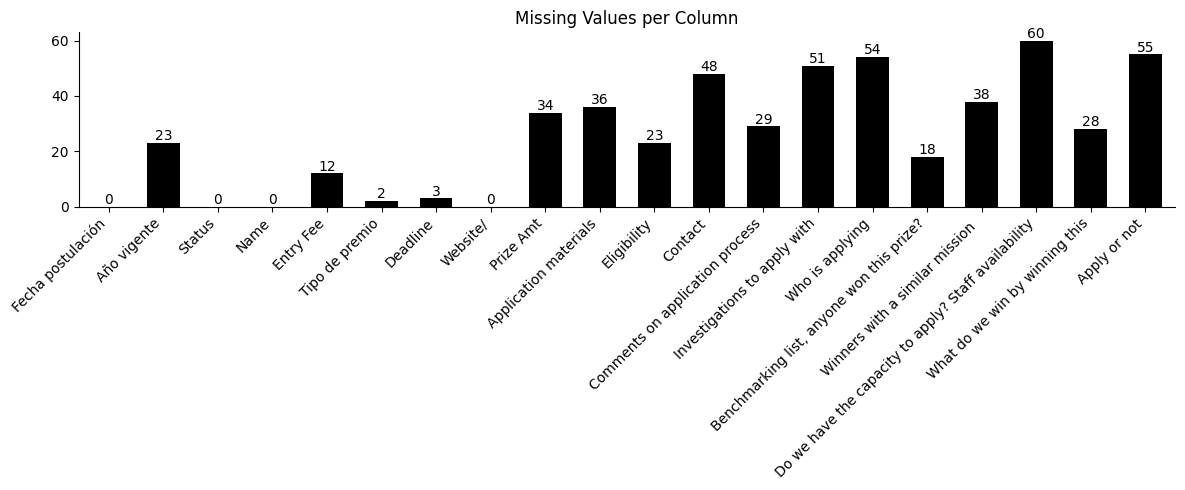

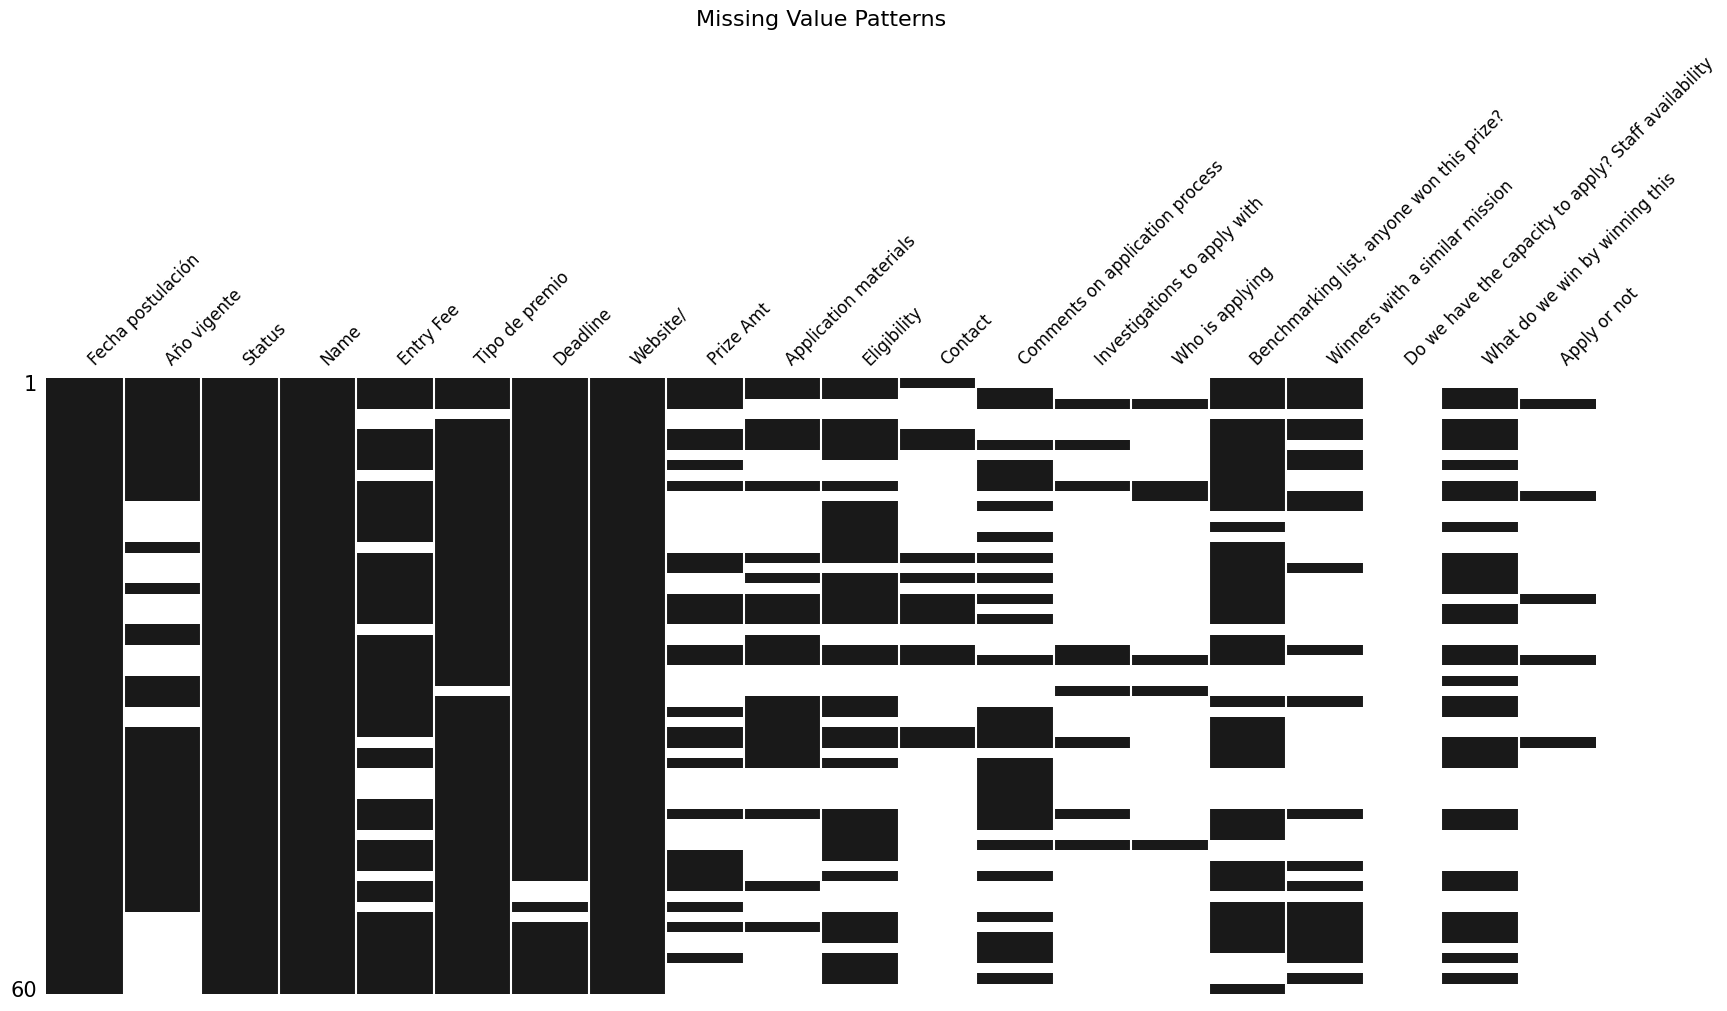

In [121]:
missing_values = df_target.isnull().sum()
print(f"Missing values per column:\n{missing_values}\n")

# Visualization 1: Bar Chart
plt.figure(figsize=(12, 5))
ax = missing_values.plot(kind='bar', color="#000000", width=0.6)
ax.grid(False)
for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height()+1, 
            f'{int(i.get_height())}', 
            ha='center', fontsize=10)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.title("Missing Values per Column")
plt.tight_layout()
plt.show()

# Visualization 2: Missingno Matrix
msno.matrix(
    df_target,
    figsize=(20, 8),
    color=(0.1, 0.1, 0.1),
    sparkline=False,
    fontsize=12,
    labels=True
)
plt.title("Missing Value Patterns", fontsize=16, pad=20)
plt.show()

## Transformation

Normalization processes for the latest duplicate

### Schema to Target

#### Column names and grouping

In [122]:
# -----------------------------
# Column rename mapping (with cleaned names)
# -----------------------------
COLUMN_MAP = {

    # Prize info
    "Name": "Name",
    "Tipo de premio": "Category",
    "Prize Amt": "Reward",
    "What do we win by winning this": "Perks",
    "Entry Fee": "Entry Fee",
    "Website/": "Website",
    "Contact": "Contact",

    # Dates & status
    # "Año vigente": "Active Year",
    "Deadline": "Deadline",
    "Fecha postulación": "Application Date",
    "Status": "Status",

    # Application details
    "Eligibility": "Eligibility",
    "Investigations to apply with": "Candidate Investigation",
    "Application materials": "Materials",
    "Comments on application process": "Notes",

    # Internal planning
    "Apply or not": "Decision",
    "Who is applying": "Assigned To",
    #"Do we have the capacity to apply? Staff availability": "Staff Capacity",

    # Research
    "Benchmarking list, anyone won this prize?": "Past Winners",
    "Winners with a similar mission": "Similar Mission Winners",
}

# Column groups with alternating background colors (applies to ALL rows)
COLUMN_GROUPS = [
    # Group 1: Basic Identification (BACKGROUND_ODD_GROUP)
    ["Name", "Reward", "Website", "Contact"],
    
    # Group 2: Time-sensitive info (no color)
    ["Decision", "Status", "Deadline", "Application Date"],
    
    # Group 3: Requirements (BACKGROUND_ODD_GROUP)
    ["Eligibility", "Category", "Entry Fee", "Candidate Investigation"],
    
    # Group 4: Research & Context (no color)
    ["Perks", "Past Winners", "Similar Mission Winners"],
    
    # Group 5: Application Logistics (BACKGROUND_ODD_GROUP)
    ["Materials", "Notes"],
    
    # Group 6: Team Workflow & Decisions (no color)
    ["Assigned To"]
]

# Flatten the groups to create the final column order
COLUMN_ORDER = [col for group in COLUMN_GROUPS for col in group]


# -----------------------------
# Color Palette
# -----------------------------
BACKGROUNDS = {
    "BACKGROUND_ODD_GROUP": "#f5f0e8",  # Warm cream for odd groups (1,3,5)
    "BACKGROUND_EVEN_GROUP": "#FFFFFF",  # White for even groups
}

HEADER = "#0f0e0c"  # Almost black
GRID = "#d4c9b0"    # Warm taupe for borders


# -----------------------------
# Helper functions
# -----------------------------
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    return {
        "red": int(hex_color[0:2], 16) / 255,
        "green": int(hex_color[2:4], 16) / 255,
        "blue": int(hex_color[4:6], 16) / 255
    }


def get_sheet_headers(service, spreadsheet_id, sheet_name):
    return service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!1:1",
        majorDimension="ROWS"
    ).execute().get("values", [[]])[0]


def get_sheet_id(service, spreadsheet_id, sheet_name):
    meta = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id
    ).execute()

    return next(
        s["properties"]["sheetId"]
        for s in meta["sheets"]
        if s["properties"]["title"] == sheet_name
    )


def get_last_row_with_data(service, spreadsheet_id, sheet_name):
    """Get the last row that contains data in the sheet"""
    result = service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!A:A",
        majorDimension="COLUMNS"
    ).execute()
    
    values = result.get("values", [[]])[0]
    return len(values)  # Returns number of rows with data in first column


def rename_headers(headers, mapping):
    return [mapping.get(h, h) for h in headers]


def filter_headers_by_mapping(headers, mapping):
    """Keep only headers that are in the mapping"""
    return [h for h in headers if h in mapping]


def compute_final_order(headers, desired_order):
    desired = [h for h in desired_order if h in headers]
    remaining = [h for h in headers if h not in desired]
    return desired + remaining


def build_move_requests(sheet_id, current, target):
    requests = []
    current_order = current.copy()

    for target_idx, col in enumerate(target):
        current_idx = current_order.index(col)

        if current_idx != target_idx:
            requests.append({
                "moveDimension": {
                    "source": {
                        "sheetId": sheet_id,
                        "dimension": "COLUMNS",
                        "startIndex": current_idx,
                        "endIndex": current_idx + 1
                    },
                    "destinationIndex": target_idx
                }
            })

            moved = current_order.pop(current_idx)
            current_order.insert(target_idx, moved)

    return requests


def build_delete_column_requests(sheet_id, headers_to_keep, all_headers):
    """Build requests to delete columns not in headers_to_keep"""
    requests = []
    
    # Get indices of columns to delete (in reverse order to avoid index shifting issues)
    indices_to_delete = []
    for i, header in enumerate(all_headers):
        if header not in headers_to_keep:
            indices_to_delete.append(i)
    
    # Delete from the end first to avoid index shifting problems
    for idx in sorted(indices_to_delete, reverse=True):
        requests.append({
            "deleteDimension": {
                "range": {
                    "sheetId": sheet_id,
                    "dimension": "COLUMNS",
                    "startIndex": idx,
                    "endIndex": idx + 1
                }
            }
        })
    
    return requests, len(indices_to_delete)


def verify_sheet_exists(service, spreadsheet_id, sheet_name):
    """Verify sheet exists and return its ID"""
    try:
        meta = service.spreadsheets().get(
            spreadsheetId=spreadsheet_id
        ).execute()
        
        for sheet in meta["sheets"]:
            if sheet["properties"]["title"] == sheet_name:
                sheet_id = sheet["properties"]["sheetId"]
                print(f"✅ Found sheet '{sheet_name}' with ID: {sheet_id}")
                return sheet_id
        
        print(f"❌ Sheet '{sheet_name}' not found. Available sheets:")
        for sheet in meta["sheets"]:
            print(f"  - '{sheet['properties']['title']}'")
        return None
        
    except Exception as e:
        print(f"❌ Error getting sheet metadata: {e}")
        return None


def build_formatting_requests(sheet_id, column_groups, last_row):
    """
    Apply BACKGROUND_ODD_GROUP to odd column groups (1,3,5)
    Header row HEADER color with white text
    Borders GRID color
    """
    requests = []

    start_index = 0
    total_cols = sum(len(g) for g in column_groups)

    # -----------------------------
    # Column group coloring
    # -----------------------------
    for i, group in enumerate(column_groups):

        end_index = start_index + len(group)

        # color only odd groups (1,3,5...) -> index 0,2,4
        if i % 2 == 0:  # Groups 1, 3, 5 (use BACKGROUND_ODD_GROUP)
            rgb_color = hex_to_rgb(BACKGROUNDS["BACKGROUND_ODD_GROUP"])

            requests.append({
                "repeatCell": {
                    "range": {
                        "sheetId": sheet_id,
                        "startRowIndex": 1,        # skip header
                        "endRowIndex": last_row,
                        "startColumnIndex": start_index,
                        "endColumnIndex": end_index
                    },
                    "cell": {
                        "userEnteredFormat": {
                            "backgroundColor": rgb_color
                        }
                    },
                    "fields": "userEnteredFormat.backgroundColor"
                }
            })
        # Even groups (2,4,6) get white background - no need to set explicitly
        # as they'll default to white, but we could set BACKGROUND_EVEN_GROUP if needed

        start_index = end_index


    # -----------------------------
    # HEADER (dark) with white text
    # -----------------------------
    requests.append({
        "repeatCell": {
            "range": {
                "sheetId": sheet_id,
                "startRowIndex": 0,
                "endRowIndex": 1,
                "startColumnIndex": 0,
                "endColumnIndex": total_cols
            },
            "cell": {
                "userEnteredFormat": {
                    "backgroundColor": hex_to_rgb(HEADER),
                    "textFormat": {
                        "foregroundColor": {"red": 1, "green": 1, "blue": 1},
                        "bold": True
                    }
                }
            },
            "fields": "userEnteredFormat(backgroundColor,textFormat)"
        }
    })


    # -----------------------------
    # GRID colored borders
    # -----------------------------
    requests.append({
        "updateBorders": {
            "range": {
                "sheetId": sheet_id,
                "startRowIndex": 0,
                "endRowIndex": last_row,
                "startColumnIndex": 0,
                "endColumnIndex": total_cols
            },
            "top": {"style": "SOLID", "color": hex_to_rgb(GRID)},
            "bottom": {"style": "SOLID", "color": hex_to_rgb(GRID)},
            "left": {"style": "SOLID", "color": hex_to_rgb(GRID)},
            "right": {"style": "SOLID", "color": hex_to_rgb(GRID)},
            "innerHorizontal": {"style": "SOLID", "color": hex_to_rgb(GRID)},
            "innerVertical": {"style": "SOLID", "color": hex_to_rgb(GRID)}
        }
    })

    return requests


# -----------------------------
# Main execution
# -----------------------------
SHEET_NAME = "aligned"  # Change this to your actual sheet name

# 0. Verify sheet exists and get ID
sheet_id = verify_sheet_exists(sheet_service, ORIGINAL_SPREADSHEET_ID, SHEET_NAME)

if sheet_id is None:
    print("❌ Cannot proceed. Fix the sheet name and try again.")
else:
    # 1. Read headers
    all_headers = get_sheet_headers(sheet_service, ORIGINAL_SPREADSHEET_ID, SHEET_NAME)
    print(f"📊 Found {len(all_headers)} columns in sheet")
    print(f"   Original columns: {', '.join(all_headers)}")
    
    # 2. Filter to keep only columns in COLUMN_MAP
    headers_to_keep = filter_headers_by_mapping(all_headers, COLUMN_MAP)
    print(f"🔍 Keeping {len(headers_to_keep)} columns (dropping {len(all_headers) - len(headers_to_keep)} columns)")
    print(f"   Columns to keep: {', '.join(headers_to_keep)}")
    
    # 3. Delete columns not in the mapping
    delete_requests, deleted_count = build_delete_column_requests(sheet_id, headers_to_keep, all_headers)
    
    if delete_requests:
        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=ORIGINAL_SPREADSHEET_ID,
            body={"requests": delete_requests}
        ).execute()
        print(f"🗑️ Deleted {deleted_count} columns not in the mapping")
    else:
        print("✅ No columns to delete")
    
    # 4. Rename headers (now to clean capitalized names)
    renamed_headers = rename_headers(headers_to_keep, COLUMN_MAP)
    print(f"✏️ Renamed headers to clean capitalized names")
    
    # 5. Compute final order
    final_order = compute_final_order(renamed_headers, COLUMN_ORDER)
    print(f"📋 Final column order has {len(final_order)} columns")
    
    # 6. Build move requests
    move_requests = build_move_requests(sheet_id, renamed_headers, final_order)
    
    # 7. Apply column moves
    if move_requests:
        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=ORIGINAL_SPREADSHEET_ID,
            body={"requests": move_requests}
        ).execute()
        print(f"🔄 Moved {len(move_requests)} columns to new positions")
    else:
        print("✅ Columns already in correct order")
    
    # 8. Update header row text with new clean names
    sheet_service.spreadsheets().values().update(
        spreadsheetId=ORIGINAL_SPREADSHEET_ID,
        range=f"{SHEET_NAME}!1:1",
        valueInputOption="RAW",
        body={"values": [final_order]}
    ).execute()
    print("📝 Updated header text to clean capitalized names")
    
    # 9. Get last row with data (after deletions)
    last_row = get_last_row_with_data(sheet_service, ORIGINAL_SPREADSHEET_ID, SHEET_NAME)
    print(f"📏 Formatting {last_row} rows of data")
    
    # 10. Apply formatting with new color palette
    formatting_requests = build_formatting_requests(sheet_id, COLUMN_GROUPS, last_row)
    
    if formatting_requests:
        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=ORIGINAL_SPREADSHEET_ID,
            body={"requests": formatting_requests}
        ).execute()
        print(f"🎨 Applied warm styling with:")
        print(f"   - Odd groups (1,3,5): {BACKGROUNDS['BACKGROUND_ODD_GROUP']} (warm cream)")
        print(f"   - Even groups (2,4,6): White")
        print(f"   - Header: {HEADER} with white text")
        print(f"   - Borders: {GRID} (warm taupe)")
    else:
        print("⚠️ No formatting requests generated")
    
    print("\n✅✅✅ DONE! Your prize tracking sheet is now beautifully organized with clean column names ✅✅✅")
    print("\n📋 New column order:")
    for i, group in enumerate(COLUMN_GROUPS, 1):
        bg = "Warm cream" if i % 2 == 1 else "White"
        print(f"   Group {i} ({bg}): {', '.join(group)}")

✅ Found sheet 'aligned' with ID: 28730282
📊 Found 20 columns in sheet
   Original columns: Fecha postulación, Año vigente, Status, Name, Entry Fee, Tipo de premio, Deadline, Website/, Prize Amt, Application materials, Eligibility, Contact, Comments on application process, Investigations to apply with, Who is applying, Benchmarking list, anyone won this prize?, Winners with a similar mission , Do we have the capacity to apply? Staff availability, What do we win by winning this, Apply or not
🔍 Keeping 17 columns (dropping 3 columns)
   Columns to keep: Fecha postulación, Status, Name, Entry Fee, Tipo de premio, Deadline, Website/, Prize Amt, Application materials, Eligibility, Contact, Comments on application process, Investigations to apply with, Who is applying, Benchmarking list, anyone won this prize?, What do we win by winning this, Apply or not
🗑️ Deleted 3 columns not in the mapping
✏️ Renamed headers to clean capitalized names
📋 Final column order has 17 columns
🔄 Moved 12 column

#### Dropdowns


###### Options

In [123]:
# Indentify Existing Dropdowns
 
def get_sheet_dropdowns(spreadsheet_id, sheet_name, creds):
    service = build('sheets', 'v4', credentials=creds)
    sheet_metadata = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        ranges=[sheet_name],
        includeGridData=True
    ).execute()

    dropdowns_by_column = {}

    for sheet in sheet_metadata['sheets']:
        if sheet['properties']['title'] != sheet_name:
            continue

        col_dropdowns = {}
        rows = sheet['data'][0]['rowData']
        header_row = rows[0]['values']
        col_names = [cell.get('formattedValue', f"Column_{i}") for i, cell in enumerate(header_row)]

        for col_idx, col_name in enumerate(col_names):
            dropdowns_in_col = set()
            for row in rows[1:]:  # Skip header
                cell = row['values'][col_idx]
                if 'dataValidation' in cell:
                    dv = cell['dataValidation']
                    if dv['condition']['type'] == 'ONE_OF_LIST':
                        values = [v['userEnteredValue'] for v in dv['condition']['values']]
                        dropdowns_in_col.update(values)
            if dropdowns_in_col:
                col_dropdowns[col_name] = list(dropdowns_in_col)

        dropdowns_by_column.update(col_dropdowns)

    return dropdowns_by_column

dropdown_options = get_sheet_dropdowns(ORIGINAL_SPREADSHEET_ID, "aligned", creds)

# Print results
for col, options in dropdown_options.items():
    print(f"🔽 {col}: {options}")


🔽 Status: ['Applying', 'Waiting for veredict', 'Decided not to apply', "Didn't win", 'Inactive', 'Won', 'Eyes on to apply soon']
🔽 Category: ['Audio / Podcast', 'tbd', 'Investigative Journalism', 'NGO / Sustanability ', 'Multimedia']


In [124]:
dropdown_options = {

    
    "Status": [
        "Open", 
        "Closed"
        
    ],

     "Decision": [
        "New Entry",
        "Apply",
        "Maybe",
        "Skip",
        "Unknown"
    ],
    
    
"Category": [
    "Investigative Journalism",
    "Cross-Border Investigation",
    "Documentary / Film",
    "Podcast / Audio",
    "Data / Visualization",
    "Research / Academic",
    "NGO / Advocacy",
    "Security / Defense",
    "Other"
]

}

In [125]:
def apply_dropdowns_to_sheet(sheet_service, spreadsheet_id, sheet_name, dropdown_options, max_rows=150000):
    
    # Get the sheet ID by matching the sheet name
    spreadsheet = sheet_service.spreadsheets().get(spreadsheetId=spreadsheet_id).execute()
    sheet_id = None
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == sheet_name:
            sheet_id = sheet['properties']['sheetId']
            break
    if sheet_id is None:
        print(f"❌ Sheet name '{sheet_name}' not found.")
        return

    # Fetch header row (assumes headers are in row 1)
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!1:1"
    ).execute()
    headers = result.get('values', [])[0]

    requests = []  # Will store all the API requests we need to make

    # Handle both direct list options and dictionary format with "official_list"
    for col_name, options in dropdown_options.items():
        if col_name not in headers:
            continue

        col_index = headers.index(col_name)
        values = (
            options.get("official_list", []) if isinstance(options, dict)
            else options
        )
        values = values[:500]  # Apparently it can only handle this, or else it breaks the API

        if not values:
            continue

    # Create data validation rule for dropdown
        validation_rule = {
            "condition": {
                "type": "ONE_OF_LIST",
                "values": [{"userEnteredValue": str(v)} for v in values]
            },
            "strict": True,
            "showCustomUi": True
        }

    # Add request for this column's dropdown
        requests.append({
            "setDataValidation": {
                "range": {
                    "sheetId": sheet_id,
                    "startRowIndex": 1,
                    "endRowIndex": max_rows,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "rule": validation_rule
            }
        })

    # Execute all requests if we have any
    if requests:
        try:
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests}
            ).execute()
            print(f"✅ Applied dropdown formatting to {len(requests)} columns.")
        except Exception as e:
            print(f"❌ Error applying dropdowns: {e}")
    else:
        print("⚠️ No matching columns found in the sheet.")
        
apply_dropdowns_to_sheet(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,  
    sheet_name="aligned",                 
    dropdown_options=dropdown_options, 
    max_rows=150000                  
)


✅ Applied dropdown formatting to 3 columns.


In [126]:
dropdown_options['Status']

['Open', 'Closed']

#### Boundaries

Trim blank rows and columns to have the exact db size.

In [127]:
def trim_sheet_to_data(sheet_service, spreadsheet_id, sheet_name):
    """Remove blank rows and columns after the end of actual data in the sheet"""
    
    # Get sheet details without grid data
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        fields="sheets(properties(sheetId,title,gridProperties(rowCount,columnCount)))"
    ).execute()

    sheet_id = None
    total_row_count = 0
    total_col_count = 0
    
    for sheet in spreadsheet["sheets"]:
        if sheet["properties"]["title"] == sheet_name:
            sheet_id = sheet["properties"]["sheetId"]
            total_row_count = sheet["properties"]["gridProperties"]["rowCount"]
            total_col_count = sheet["properties"]["gridProperties"]["columnCount"]
            break

    if sheet_id is None:
        raise ValueError(f"Sheet '{sheet_name}' not found")

    print(f"Scanning sheet '{sheet_name}' for data boundaries...")
    
    # Get all data at once for more efficient column scanning
    try:
        result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=sheet_name,
            majorDimension="ROWS"
        ).execute()
        
        values = result.get('values', [])
        
        if not values:
            print(f"No data found in sheet '{sheet_name}'. No trimming needed.")
            return total_row_count, total_col_count
        
        # Find last row with data
        last_data_row = 0
        for row_idx in range(len(values) - 1, -1, -1):
            row = values[row_idx]
            has_data = any(cell and str(cell).strip() for cell in row)
            if has_data:
                last_data_row = row_idx + 1  # Convert to 1-based index
                break
        
        # Find last column with data
        last_data_col = 0
        # Transpose to scan by columns
        max_cols = max(len(row) for row in values) if values else 0
        for col_idx in range(max_cols - 1, -1, -1):
            has_data = False
            for row in values:
                if col_idx < len(row) and row[col_idx] and str(row[col_idx]).strip():
                    has_data = True
                    break
            if has_data:
                last_data_col = col_idx + 1  # Convert to 1-based index
                break
        
        # Prepare batch update requests
        requests = []
        
        # Delete blank rows if needed
        if last_data_row < total_row_count:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "ROWS",
                        "startIndex": last_data_row,
                        "endIndex": total_row_count
                    }
                }
            })
        
        # Delete blank columns if needed
        if last_data_col < total_col_count:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "COLUMNS",
                        "startIndex": last_data_col,
                        "endIndex": total_col_count
                    }
                }
            })
        
        # Execute batch update if there are changes
        if requests:
            delete_request = {"requests": requests}
            
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body=delete_request
            ).execute()
            
            rows_trimmed = total_row_count - last_data_row if last_data_row < total_row_count else 0
            cols_trimmed = total_col_count - last_data_col if last_data_col < total_col_count else 0
            
            print(f"Trimmed {rows_trimmed} blank rows and {cols_trimmed} blank columns from sheet '{sheet_name}'.")
            print(f"New dimensions: {last_data_row} rows × {last_data_col} columns")
            
            return last_data_row, last_data_col
        else:
            print(f"No blank rows or columns to trim in sheet '{sheet_name}'.")
            return total_row_count, total_col_count
            
    except Exception as e:
        print(f"Error processing sheet '{sheet_name}': {e}")
        return total_row_count, total_col_count


# Usage
trim_sheet_to_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")

Scanning sheet 'aligned' for data boundaries...
Trimmed 935 blank rows and 8 blank columns from sheet 'aligned'.
New dimensions: 61 rows × 17 columns


(61, 17)

#### Drop blanks

In [128]:
def drop_blank_rows(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop rows that are entirely blank (all values are NaN or empty string).
    
    Args:
        df: Input DataFrame
    
    Returns:
        DataFrame without blank rows
    """
    df_cleaned = df.replace("", pd.NA).dropna(how="all").reset_index(drop=True)
    return df_cleaned

df_target = drop_blank_rows(df_target)


In [129]:
def delete_all_blank_rows(sheet_service, spreadsheet_id, sheet_name):
    """Delete all completely blank rows within the data area of the sheet"""
    
    # Get sheet details
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        fields="sheets(properties(sheetId,title))"
    ).execute()

    sheet_id = None
    for sheet in spreadsheet["sheets"]:
        if sheet["properties"]["title"] == sheet_name:
            sheet_id = sheet["properties"]["sheetId"]
            break

    if sheet_id is None:
        raise ValueError(f"Sheet '{sheet_name}' not found")

    print(f"Scanning sheet '{sheet_name}' for blank rows...")
    
    # Get all data
    try:
        result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=sheet_name,
            majorDimension="ROWS"
        ).execute()
        
        values = result.get('values', [])
        
        if not values:
            print(f"No data found in sheet '{sheet_name}'. No rows to delete.")
            return 0
        
        # Identify blank rows (bottom-up to maintain index integrity)
        blank_row_indices = []
        for row_idx in range(len(values) - 1, -1, -1):
            row = values[row_idx]
            # Check if row is completely empty or has only empty strings
            is_blank = True
            for cell in row:
                if cell and str(cell).strip():
                    is_blank = False
                    break
            
            if is_blank:
                blank_row_indices.append(row_idx)
        
        if not blank_row_indices:
            print(f"No blank rows found in sheet '{sheet_name}'.")
            return 0
        
        # Sort indices in descending order for batch deletion
        blank_row_indices.sort(reverse=True)
        
        # Create batch delete requests (delete rows from bottom to top)
        requests = []
        for row_idx in blank_row_indices:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "ROWS",
                        "startIndex": row_idx,
                        "endIndex": row_idx + 1
                    }
                }
            })
        
        # Execute batch deletion
        delete_request = {"requests": requests}
        
        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=delete_request
        ).execute()
        
        print(f"Deleted {len(blank_row_indices)} blank rows from sheet '{sheet_name}'.")
        return len(blank_row_indices)
            
    except Exception as e:
        print(f"Error processing sheet '{sheet_name}': {e}")
        return 0
    
delete_all_blank_rows(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")

Scanning sheet 'aligned' for blank rows...
No blank rows found in sheet 'aligned'.


0

#### uID

In [130]:
def add_uid_column(sheet_service, spreadsheet_id, sheet_name, uid_col_name="uid"):
    import uuid
    import time
    from googleapiclient.errors import HttpError

    MAX_RETRIES = 3
    RETRY_DELAY = 2  # seconds
    CHUNK_SIZE = 1000

    def execute_with_retry(api_call, *args, **kwargs):
        """Execute API call with retry logic for rate limiting and transient errors"""
        for attempt in range(MAX_RETRIES):
            try:
                return api_call(*args, **kwargs).execute()
            except HttpError as e:
                if e.resp.status in [429, 500, 503]:  # Rate limit or server errors
                    if attempt < MAX_RETRIES - 1:
                        sleep_time = RETRY_DELAY * (2 ** attempt)  # Exponential backoff
                        print(f"Rate limited, retrying in {sleep_time}s (attempt {attempt + 1}/{MAX_RETRIES})")
                        time.sleep(sleep_time)
                        continue
                raise
            except Exception as e:
                if attempt < MAX_RETRIES - 1:
                    print(f"Error occurred, retrying in {RETRY_DELAY}s (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
                    time.sleep(RETRY_DELAY)
                    continue
                raise
        return None

    def column_index_to_a1(column_index):
        """Convert zero-based column index to A1 notation"""
        result = ""
        while column_index >= 0:
            result = chr(65 + (column_index % 26)) + result
            column_index = (column_index // 26) - 1
        return result

    try:
        # Get sheet metadata
        spreadsheet = execute_with_retry(
            sheet_service.spreadsheets().get,
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title,gridProperties(rowCount,columnCount)))"
        )

        sheet_id = None
        row_count = 0
        original_col_count = 0
        
        for sheet in spreadsheet["sheets"]:
            if sheet["properties"]["title"] == sheet_name:
                sheet_id = sheet["properties"]["sheetId"]
                row_count = sheet["properties"]["gridProperties"]["rowCount"]
                original_col_count = sheet["properties"]["gridProperties"]["columnCount"]
                break

        if sheet_id is None:
            raise ValueError(f"Sheet '{sheet_name}' not found in spreadsheet")

        # Check if UID column already exists
        result = execute_with_retry(
            sheet_service.spreadsheets().values().get,
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}!1:1"
        )
        
        values = result.get('values', [])
        headers = values[0] if values else []
        
        # Find existing UID column
        existing_uid_col_index = None
        for i, header in enumerate(headers):
            if header == uid_col_name:
                existing_uid_col_index = i
                break

        # If UID column exists, use it instead of creating a new one
        if existing_uid_col_index is not None:
            print(f"UID column '{uid_col_name}' already exists at column {existing_uid_col_index + 1}")
            insert_col_index = existing_uid_col_index
            col_letter = column_index_to_a1(insert_col_index)
            
            # Clear existing values (keep header)
            clear_range = f"{sheet_name}!{col_letter}2:{col_letter}{row_count}"
            execute_with_retry(
                sheet_service.spreadsheets().values().clear,
                spreadsheetId=spreadsheet_id,
                range=clear_range,
                body={}
            )
        else:
            # Find the last column with data
            last_col_with_data = len(headers) if headers else 0
            
            # If we're at the grid boundary, we need to append rather than insert
            if last_col_with_data >= original_col_count:
                # Append a new column by updating the sheet's grid properties
                append_request = {
                    "updateSheetProperties": {
                        "properties": {
                            "sheetId": sheet_id,
                            "gridProperties": {
                                "columnCount": original_col_count + 1
                            }
                        },
                        "fields": "gridProperties.columnCount"
                    }
                }
                
                execute_with_retry(
                    sheet_service.spreadsheets().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body={"requests": [append_request]}
                )
                
                insert_col_index = original_col_count
                col_letter = column_index_to_a1(insert_col_index)
                
                # Set the header for the new column
                header_range = f"{sheet_name}!{col_letter}1"
                execute_with_retry(
                    sheet_service.spreadsheets().values().update,
                    spreadsheetId=spreadsheet_id,
                    range=header_range,
                    valueInputOption="RAW",
                    body={"values": [[uid_col_name]]}
                )
            else:
                # We have room to insert a column
                insert_col_index = last_col_with_data
                col_letter = column_index_to_a1(insert_col_index)

                # Batch requests for inserting column and setting header
                batch_requests = [
                    {
                        "insertDimension": {
                            "range": {
                                "sheetId": sheet_id,
                                "dimension": "COLUMNS",
                                "startIndex": insert_col_index,
                                "endIndex": insert_col_index + 1
                            },
                            "inheritFromBefore": False
                        }
                    },
                    {
                        "updateCells": {
                            "rows": [
                                {"values": [{"userEnteredValue": {"stringValue": uid_col_name}}]}
                            ],
                            "fields": "userEnteredValue",
                            "start": {"sheetId": sheet_id, "rowIndex": 0, "columnIndex": insert_col_index}
                        }
                    }
                ]

                # Execute batch update
                execute_with_retry(
                    sheet_service.spreadsheets().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body={"requests": batch_requests}
                )

        # Generate UUIDs and update values in chunks
        if row_count > 1:  # Only if there are data rows
            for start_row in range(1, row_count, CHUNK_SIZE):
                end_row = min(start_row + CHUNK_SIZE, row_count)
                num_rows = end_row - start_row
                
                values = [[str(uuid.uuid4())] for _ in range(num_rows)]
                
                range_uid = f"{sheet_name}!{col_letter}{start_row + 1}:{col_letter}{end_row}"
                
                body = {
                    "valueInputOption": "RAW",
                    "data": [{"range": range_uid, "values": values}]
                }

                execute_with_retry(
                    sheet_service.spreadsheets().values().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body=body
                )
                
                # Add a small delay between chunks to avoid rate limiting
                if end_row < row_count:
                    time.sleep(1)

        print(f"UID column '{uid_col_name}' {'updated' if existing_uid_col_index is not None else 'added'} "
              f"in sheet '{sheet_name}' at column {col_letter} ({insert_col_index + 1})")
        
        return insert_col_index, col_letter

    except HttpError as e:
        print(f"Google Sheets API error: {e}")
        raise
    except Exception as e:
        print(f"Unexpected error: {e}")
        raise


# Usage example with comprehensive error handling
try:
    column_index, column_letter = add_uid_column(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
    print(f"Operation completed successfully. UID column at {column_letter} (index {column_index})")
    
except ValueError as e:
    print(f"Configuration error: {e}")
except HttpError as e:
    if e.resp.status == 404:
        print(f"Spreadsheet or sheet not found: {e}")
    elif e.resp.status == 403:
        print(f"Permission denied: {e}")
    else:
        print(f"Google Sheets API error: {e}")
except TimeoutError:
    print("Timeout occurred. Please check your network connection and try again.")
except Exception as e:
    print(f"Unexpected error: {e}")

UID column 'uid' added in sheet 'aligned' at column R (18)
Operation completed successfully. UID column at R (index 17)


In [131]:
def get_sheet_data(sheet_service, spreadsheet_id, sheet_name):
    range_name = f"{sheet_name}"
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    values = result.get('values', [])
    if not values:
        return pd.DataFrame()

    headers = values[0]
    num_cols = len(headers)

    # Truncate each row to header length, pad short rows with ''
    normalized_rows = [
        (row[:num_cols] + [''] * (num_cols - len(row)))
        for row in values[1:]
    ]

    return pd.DataFrame(normalized_rows, columns=headers)

df_target = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
df_target = df_target.replace('', pd.NA)  # Convert empty strings to NA
df_target = df_target.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


#### Remove filters

In [132]:
from googleapiclient.errors import HttpError

def remove_sheet_filters(spreadsheet_id, sheet_name):
    """
    Remove all filters from a specific sheet in a Google Spreadsheet
    """
    try:
        # Get spreadsheet metadata to find the sheet ID
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title))"
        ).execute()
        
        # Find the specific sheet ID
        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break
        
        if not sheet_id:
            print(f"Sheet '{sheet_name}' not found")
            return False
        
        # Create request to clear filters
        requests = [{
            'clearBasicFilter': {
                'sheetId': sheet_id
            }
        }]
        
        # Execute the request
        body = {'requests': requests}
        response = sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=body
        ).execute()
        
        print(f"✅ Successfully removed all filters from '{sheet_name}'")
        return True
        
    except HttpError as error:
        print(f"❌ An HTTP error occurred: {error}")
        return False
    except Exception as error:
        print(f"❌ An error occurred: {error}")
        return False

# Usage
SPREADSHEET_ID = ORIGINAL_SPREADSHEET_ID  
SHEET_NAME = "aligned"  

# Remove filters only
success = remove_sheet_filters(SPREADSHEET_ID, SHEET_NAME)
if success:
    print("Filters removed successfully!")
else:
    print("Failed to remove filters.")

✅ Successfully removed all filters from 'aligned'
Filters removed successfully!


### Refresh

In [133]:
# Update after applying schema
def get_sheet_data(sheet_service, spreadsheet_id, sheet_name):
    range_name = f"{sheet_name}"  # Add and adjust range if needed 
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    values = result.get('values', [])
    if not values:
        return pd.DataFrame()  # Return empty if no data
    return pd.DataFrame(values[1:], columns=values[0])  # Row 0 = headers

# Fetch data 
df_target = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
df_target = df_target.replace('', pd.NA)  # Convert empty strings to NA
df_target = df_target.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


In [134]:
def get_dataframe_summary(df_target):
    
    # --- General DataFrame Info ---
    general_info = {
        "Shape": f"{df_target.shape[0]} rows × {df_target.shape[1]} cols",
        "Memory Usage": f"{df_target.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB",
        "Columns with NA": f"{df_target.isna().any().sum()} of {len(df_target.columns)}",
        "Duplicate Rows": f"{df_target.duplicated().sum()} ({(df_target.duplicated().mean() * 100):.1f}%)",
        "Numeric Columns": f"{df_target.select_dtypes(include='number').shape[1]}",
        "Categorical Columns": f"{df_target.select_dtypes(include=['object', 'category']).shape[1]}",
        "Datetime Columns": f"{df_target.select_dtypes(include='datetime').shape[1]}"
    }

    # --- Compute dropdown options per column ---
    dropdown_options_dict = {
        col: dropdown_options.get(col, [])
        for col in df_target.columns
    }
    
    # --- Column-Level Stats ---
    column_stats = pd.DataFrame({
        'Variable': df_target.columns,
        'Dtype': df_target.dtypes.values,
        'Unique_Count': df_target.nunique().values,
        'NA_Count': df_target.isna().sum().values,
        'NA_Percentage': (df_target.isna().mean() * 100).round(1).values,
        'Duplicate_Count': df_target.apply(lambda col: col.duplicated(keep=False).sum()).values,
        'Duplicate_Percentage': (df_target.apply(lambda col: col.duplicated(keep=False).mean()) * 100).round(1).values,
        'Unique_Values': df_target.apply(lambda x: x.drop_duplicates().tolist()).values,
        'Dropdown_Options': [dropdown_options_dict[col] for col in df_target.columns],
        'Dropdown_Option_Count': [len(dropdown_options_dict[col]) for col in df_target.columns]
    }).sort_values('Unique_Count', ascending=False)
        # --- Format percentages ---
    column_stats['NA_Percentage'] = column_stats['NA_Percentage'].astype(str) + '%'
    column_stats['Duplicate_Percentage'] = column_stats['Duplicate_Percentage'].astype(str) + '%'

    return general_info, column_stats

# Run the summary
general_info, column_stats = get_dataframe_summary(df_target)

# Print General Info
print("=== GENERAL DATAFRAME INFO ===")
for key, value in general_info.items():
    print(f"{key}: {value}")


# Display Column Stats (including dropdown options)
print("\n=== COLUMN-LEVEL STATISTICS ===")
display(column_stats)

=== GENERAL DATAFRAME INFO ===
Shape: 60 rows × 18 cols
Memory Usage: 0.10 MB
Columns with NA: 13 of 18
Duplicate Rows: 0 (0.0%)
Numeric Columns: 0
Categorical Columns: 18
Datetime Columns: 0

=== COLUMN-LEVEL STATISTICS ===


/tmp/ipykernel_593000/3431749046.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  "Categorical Columns": f"{df_target.select_dtypes(include=['object', 'category']).shape[1]}",


,Variable,Dtype,Unique_Count,NA_Count,NA_Percentage,Duplicate_Count,Duplicate_Percentage,Unique_Values,Dropdown_Options,Dropdown_Option_Count
0,Name,str,60,0,0.0%,0,0.0%,[IRE Awards -- Investigative Reporters and Edi...,[],0
2,Website,str,60,0,0.0%,0,0.0%,"[https://ire.org/awards/ire-awards/faq/, http:...",[],0
17,uid,str,60,0,0.0%,0,0.0%,"[f2da3fdd-0d69-4df4-b9f3-078c107d8930, 667b94e...",[],0
6,Deadline,str,56,3,5.0%,5,8.3%,"[\nJan 15, 2026, January 30 2026, January 20 2...",[],0
13,Past Winners,str,38,18,30.0%,25,41.7%,"[Propublica, The Globe And Mail, Bloomberg, na...",[],0
8,Eligibility,str,37,23,38.3%,23,38.3%,[Entries will be judged on the basis of the IR...,[],0
10,Entry Fee,str,37,12,20.0%,28,46.7%,"[$55 members, $125 nonmembers (at least one me...",[],0
15,Notes,str,31,29,48.3%,29,48.3%,"[nan, Aplicamos en 2022 con: IGSS Pisa, Petén ...",[],0
1,Reward,str,24,34,56.7%,38,63.3%,"[medal for outstanding crime reporting, , USD ...",[],0
14,Materials,str,24,36,60.0%,36,60.0%,[1. Complete questionnaire:https://ire.org/med...,[],0


### Possible formatting

In [135]:
# unique values in column Decision
unique_decision_values = df_target['Decision'].dropna().unique()
print(f"Unique values in 'Decision' column: {unique_decision_values}")

# unique values in column Status
unique_status_values = df_target['Status'].dropna().unique()
print(f"Unique values in 'Status' column: {unique_status_values}")

# unique values in column Deadline
unique_deadline_values = df_target['Deadline'].dropna().unique()
print(f"Unique values in 'Deadline' column: {unique_deadline_values}")

# unique values in column Application Date
unique_application_date_values = df_target['Application Date'].dropna().unique()
print(f"Unique values in 'Application Date' column: {unique_application_date_values}")

Unique values in 'Decision' column: <StringArray>
['si', 'yes', 'No', 'SI']
Length: 4, dtype: str
Unique values in 'Status' column: <StringArray>
['Eyes on to apply soon',              'Applying',  'Decided not to apply',
              'Inactive',                   'Won',            'Didn't win',
  'Waiting for veredict']
Length: 7, dtype: str
Unique values in 'Deadline' column: <StringArray>
[                                       '\nJan 15, 2026',
                                       'January 30 2026',
                                       'January 20 2026',
                                           'December 31',
                                       'January 27 2026',
                                        'January 8 2026',
                                      'January 31, 2026',
                                          'Jan 28, 2025',
                                      'January 30, 2026',
                                            'Julio 2025',
                        

##### Decision

In [136]:
def standardize_decision_column(sheet_service, spreadsheet_id, sheet_name="aligned"):
    """
    Standardize Decision column values:
    - 'si', 'yes', 'SI' → 'Apply'
    - 'no' → 'Skip'
    - All other values (including empty cells) → 'Unknown'
    """
    try:
        # Read all data from the sheet
        result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=sheet_name
        ).execute()
        
        values = result.get('values', [])
        
        if not values:
            print(f"No data found in sheet '{sheet_name}'.")
            return False
            
        headers = values[0]
        print(f"📋 Headers found: {headers}")
        
        if 'Decision' not in headers:
            print("❌ Column 'Decision' not found in headers.")
            return False
            
        decision_idx = headers.index('Decision')
        print(f"📍 Decision column at index: {decision_idx}")
        
        # Show original values before changes
        print("\n🔍 Original Decision values (first 10 rows):")
        for i in range(1, min(11, len(values))):
            row = values[i]
            current = row[decision_idx] if len(row) > decision_idx and row[decision_idx] else '(empty)'
            print(f"  Row {i+1}: '{current}'")
        
        # Track statistics
        stats = {
            'Apply': 0,
            'Skip': 0,
            'Unknown': 0,
            'Changed': 0
        }
        
        # Process each row (skip header row)
        changes_made = False
        for i in range(1, len(values)):
            row = values[i]
            
            # Ensure row has enough columns
            while len(row) <= decision_idx:
                row.append('')
            
            # Get current decision value and clean it
            current_value = row[decision_idx] if row[decision_idx] else ''
            clean_value = str(current_value).strip().lower()
            
            # Determine new value based on rules
            if clean_value in ['si', 'yes']:
                new_value = 'Apply'
                stats['Apply'] += 1
            elif clean_value == 'no':
                new_value = 'Skip'
                stats['Skip'] += 1
            else:
                # Everything else becomes Unknown (including empty cells, random text, etc.)
                new_value = 'Unknown'
                stats['Unknown'] += 1
            
            # Update if value is different
            if row[decision_idx] != new_value:
                print(f"  Changing row {i+1}: '{row[decision_idx]}' → '{new_value}'")
                row[decision_idx] = new_value
                stats['Changed'] += 1
                changes_made = True
        
        if not changes_made:
            print("\n✅ No changes needed - Decision column already standardized")
            print(f"   Current distribution: Apply={stats['Apply']}, Skip={stats['Skip']}, Unknown={stats['Unknown']}")
            return True
        
        # Write back the entire sheet
        print(f"\n📝 Writing {len(values)} rows back to sheet '{sheet_name}'...")
        
        update_result = sheet_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range=sheet_name,
            valueInputOption="USER_ENTERED",
            body={"values": values}
        ).execute()
        
        print(f"✅ Update successful: {update_result.get('updatedCells')} cells updated")
        print(f"\n📊 Standardization complete:")
        print(f"   - 'Apply': {stats['Apply']} rows (from 'si', 'yes')")
        print(f"   - 'Skip': {stats['Skip']} rows (from 'no')")
        print(f"   - 'Unknown': {stats['Unknown']} rows (everything else including empty cells)")
        print(f"   - Total changes made: {stats['Changed']} rows")
        
        # Verify the changes by reading back
        print("\n🔍 Verifying changes (first 10 rows after update):")
        verify_result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}!A:Z"
        ).execute()
        
        verify_values = verify_result.get('values', [])
        if len(verify_values) > 1:
            for i in range(1, min(11, len(verify_values))):
                row = verify_values[i]
                new_value = row[decision_idx] if len(row) > decision_idx and row[decision_idx] else '(empty)'
                print(f"  Row {i+1}: '{new_value}'")
        
        return True
        
    except Exception as e:
        print(f"❌ Error standardizing Decision column: {e}")
        import traceback
        traceback.print_exc()
        return False

# Run with clear print statements to see what's happening
print("="*60)
print("🚀 STARTING DECISION COLUMN STANDARDIZATION")
print("="*60)
print("📌 Rules:")
print("   - 'si/yes' → 'Apply'")
print("   - 'no' → 'Skip'")
print("   - Everything else (including empty cells) → 'Unknown'")

standardize_decision_column(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")

print("\n" + "="*60)
print("✅ PROCESS COMPLETE - Check your Google Sheet")
print("="*60)

🚀 STARTING DECISION COLUMN STANDARDIZATION
📌 Rules:
   - 'si/yes' → 'Apply'
   - 'no' → 'Skip'
   - Everything else (including empty cells) → 'Unknown'
📋 Headers found: ['Name', 'Reward', 'Website', 'Contact', 'Decision', 'Status', 'Deadline', 'Application Date', 'Eligibility', 'Category', 'Entry Fee', 'Candidate Investigation', 'Perks', 'Past Winners', 'Materials', 'Notes', 'Assigned To', 'uid']
📍 Decision column at index: 4

🔍 Original Decision values (first 10 rows):
  Row 2: '(empty)'
  Row 3: '(empty)'
  Row 4: 'si'
  Row 5: '(empty)'
  Row 6: '(empty)'
  Row 7: '(empty)'
  Row 8: '(empty)'
  Row 9: '(empty)'
  Row 10: '(empty)'
  Row 11: '(empty)'
  Changing row 2: '' → 'Unknown'
  Changing row 3: '' → 'Unknown'
  Changing row 4: 'si' → 'Apply'
  Changing row 5: '' → 'Unknown'
  Changing row 6: '' → 'Unknown'
  Changing row 7: '' → 'Unknown'
  Changing row 8: '' → 'Unknown'
  Changing row 9: '' → 'Unknown'
  Changing row 10: '' → 'Unknown'
  Changing row 11: '' → 'Unknown'
  Chan

## Delivery

In [138]:
# Function to duplicate an existing sheet and keep it hidden
def duplicate_sheet_hidden(sheet_service, spreadsheet_id, source_sheet_name, new_sheet_name):
    # First get the sheet ID of the source sheet
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id
    ).execute()
    
    # Check if the target sheet already exists
    target_sheet_exists = False
    source_sheet_id = None
    
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == new_sheet_name:
            target_sheet_exists = True
        if sheet['properties']['title'] == source_sheet_name:
            source_sheet_id = sheet['properties']['sheetId']
    
    if source_sheet_id is None:
        raise ValueError(f"Sheet '{source_sheet_name}' not found")
    
    # If aligned sheet already exists, delete it first
    if target_sheet_exists:
        # Find the sheet ID of the existing target sheet
        target_sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == new_sheet_name:
                target_sheet_id = sheet['properties']['sheetId']
                break
        
        if target_sheet_id is not None:
            # Delete the existing sheet
            delete_request = {
                "requests": [
                    {
                        "deleteSheet": {
                            "sheetId": target_sheet_id
                        }
                    }
                ]
            }
            
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body=delete_request
            ).execute()
            print(f"Deleted existing sheet '{new_sheet_name}'")
    
    # Create a duplicate of the sheet
    batch_update_request = {
        "requests": [
            {
                "duplicateSheet": {
                    "sourceSheetId": source_sheet_id,
                    "insertSheetIndex": 8,  # Position where to insert the new sheet
                    "newSheetName": new_sheet_name
                }
            }
        ]
    }
    
    # Execute the batch update to duplicate the sheet
    response = sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=batch_update_request
    ).execute()
    
    # Get the ID of the newly created sheet
    new_sheet_id = response['replies'][0]['duplicateSheet']['properties']['sheetId']
    
    # Update the sheet properties to hide it
    hide_request = {
        "requests": [
            {
                "updateSheetProperties": {
                    "properties": {
                        "sheetId": new_sheet_id,
                        "hidden": False  # Set to True to hide the sheet
                    },
                    "fields": "hidden"
                }
            }
        ]
    }
    
    # Execute the batch update to hide the sheet
    sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=hide_request
    ).execute()
    
    print(f"Duplicated sheet '{source_sheet_name}' to hidden sheet '{new_sheet_name}'")
    return response

# Usage
duplicate_sheet_hidden(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned", "delivery")

Duplicated sheet 'aligned' to hidden sheet 'delivery'


{'spreadsheetId': '1xiG4toSEaVFC_f1Kw5Dr-Md9ZD4UC09P8caOK3283Yg',
 'replies': [{'duplicateSheet': {'properties': {'sheetId': 56044737,
     'title': 'delivery',
     'index': 8,
     'sheetType': 'GRID',
     'gridProperties': {'rowCount': 61,
      'columnCount': 18,
      'frozenRowCount': 1,
      'hideGridlines': True,
      'rowGroupControlAfter': True,
      'columnGroupControlAfter': True}}}}]}

# End

In [ ]:
end_time = time.time()
end_readable = time.ctime(end_time)
execution_time = (end_time - start_time)/60


print(f"Start: {formatted_start_time}")
print(f"End: {end_readable}")
print(f"Execution time: {execution_time:.2f} minutes")

print("="*80)